# 05 - Customer segmentation (descriptive)

Groups the 682 borrowers by pre-loan transaction habits with KMeans.
Clustering uses only behavioral features, never the target, so the segments
describe habits first. Default rate per segment is computed after, as commentary.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme()
plt.rcParams.update({"axes.titlesize": 13, "axes.titleweight": "semibold"})
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

ROOT = Path("..") if Path("../data").exists() else Path(".")
DATA_DIR = ROOT / "data"
FIG_DIR = ROOT / "outputs" / "figures"
OUT_DIR = FIG_DIR.parent
FIG_DIR.mkdir(parents=True, exist_ok=True)

BEHAV = ["n_txn", "n_deposit", "n_withdrawal", "sum_deposit", "sum_withdrawal",
         "avg_amount", "std_amount", "avg_balance", "min_balance", "max_balance",
         "balance_at_loan", "months_active", "txn_per_month"]

f = pd.read_csv(DATA_DIR / "loan_features.csv")
Z = StandardScaler().fit_transform(f[BEHAV])
print(f.shape)

(682, 27)


In [2]:
scores, inertia = {}, {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Z)
    scores[k] = silhouette_score(Z, km.labels_)
    inertia[k] = float(km.inertia_)
print({k: round(v, 3) for k, v in scores.items()})
print({k: round(v) for k, v in inertia.items()})  # elbow reference
best_k = max(scores, key=scores.get)
print("best k:", best_k)

{2: 0.294, 3: 0.269, 4: 0.251, 5: 0.235, 6: 0.238}
{2: 6112, 3: 4741, 4: 3997, 5: 3593, 6: 3263}
best k: 2


In [3]:
f["segment"] = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit_predict(Z)
prof = f.groupby("segment")[BEHAV].median().round(1)
prof["size"] = f["segment"].value_counts().sort_index()
prof["default_rate"] = f.groupby("segment")["target"].mean().round(3)
print(prof[["size", "n_txn", "avg_balance", "balance_at_loan", "txn_per_month", "default_rate"]].to_string())
prof.to_csv(OUT_DIR / "segment_profiles.csv")
print("saved segment_profiles.csv")

         size  n_txn  avg_balance  balance_at_loan  txn_per_month  default_rate
segment                                                                        
0         421   54.0      37189.8          34917.4            5.2         0.124
1         261  116.0      52422.5          47992.1            6.9         0.092
saved segment_profiles.csv


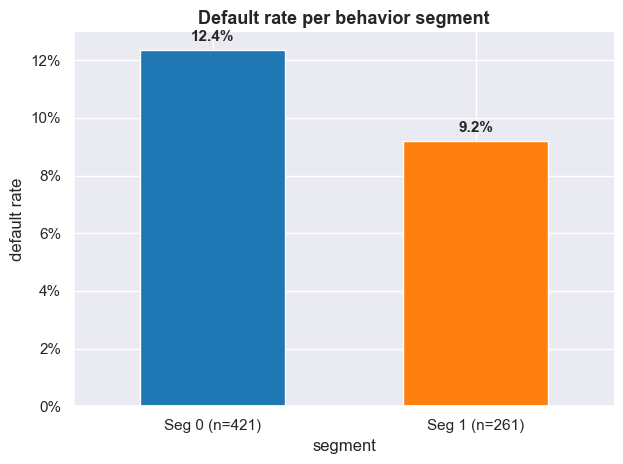

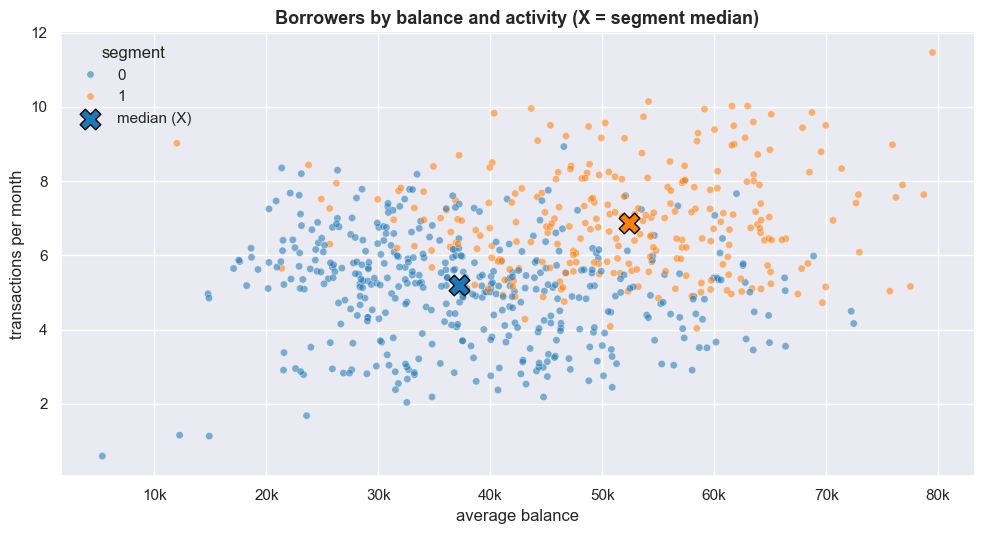

In [4]:
SEG = sns.color_palette("tab10", best_k)
rates = f.groupby("segment")["target"].mean()
sizes = f["segment"].value_counts().sort_index()
assert len(SEG) == best_k
ax = rates.plot.bar(color=SEG, edgecolor="white", width=0.55)
ax.set_title("Default rate per behavior segment")
ax.set_ylabel("default rate")
ax.set_xlabel("segment")
ax.set_xticklabels([f"Seg {s} (n={sizes[s]})" for s in rates.index], rotation=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
for bar, r in zip(ax.patches, rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002, f"{r:.1%}",
            ha="center", va="bottom", fontsize=11, fontweight="semibold")
sns.despine()
plt.tight_layout()
plt.savefig(FIG_DIR / "segments_default.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.scatterplot(data=f, x="avg_balance", y="txn_per_month", hue="segment",
                palette=SEG, alpha=0.55, s=28, edgecolor="white", linewidth=0.4, ax=ax)
for i, (s, color) in enumerate(zip(sorted(f["segment"].unique()), SEG)):
    g = f.loc[f["segment"] == s]
    ax.scatter(g["avg_balance"].median(), g["txn_per_month"].median(), s=220, marker="X",
               color=color, edgecolor="black", linewidth=1, zorder=5,
               label="median (X)" if i == 0 else None)
ax.set_title("Borrowers by balance and activity (X = segment median)")
ax.set_xlabel("average balance")
ax.set_ylabel("transactions per month")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v / 1000:.0f}k"))
ax.legend(title="segment", frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig(FIG_DIR / "segments_scatter.png", dpi=150, bbox_inches="tight")
plt.show()


In [5]:
assert f["segment"].notna().all() and f["segment"].nunique() == best_k
assert f.groupby("segment")["target"].mean().between(0, 1).all()
assert scores[best_k] >= 0.2, f"silhouette too weak: {scores[best_k]:.3f}"
assert best_k == max(scores, key=scores.get), "best_k must maximize silhouette"
print(f"segmentation checks passed (k={best_k}, silhouette={scores[best_k]:.3f})")

segmentation checks passed (k=2, silhouette=0.294)
